# Superstore Sales Analysis using Python
## Project Overview
## Objective

The objective of this project is to analyze the Superstore sales dataset using Python and perform exploratory data analysis (EDA) to uncover valuable business insights. The analysis focuses on sales performance, profitability, customer behavior, product performance, shipping efficiency, and sales trends over time.

## Business Questions

This analysis aims to answer the following questions:

- Which region generates the highest sales and profit?
- Which product categories perform the best?
- Which products generate the highest revenue and profit?
- Which products are causing losses?
- Who are the most valuable customers?
- How do sales change over time?
- Which shipping mode performs best?
- Does discount affect profitability?


## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Dataset Information

The dataset contains transactional records from a retail superstore. It includes customer information, product details, sales, profit, discounts, shipping information, and geographical data.

## 1. Import Libraries

In [1]:
# import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
# load dataset in dataframe
df = pd.read_csv("sample_-_superstore.csv")

## 3. Data Inspection

In this section, the dataset is explored to understand its structure, identify missing values, duplicates, and examine data types before analysis.

In [3]:
df.shape

(10194, 21)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [5]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  str    
 6   Customer Name   10194 non-null  str    
 7   Segment         10194 non-null  str    
 8   Country/Region  10194 non-null  str    
 9   City            10194 non-null  str    
 10  State/Province  10194 non-null  str    
 11  Postal Code     10194 non-null  str    
 12  Region          10194 non-null  str    
 13  Product ID      10194 non-null  str    
 14  Category        10194 non-null  str    
 15  Sub-Category    10194 non-null  str    
 16  Product Name    10194 non-null  str    
 17  Sales           10194 non-null  float64
 1

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,228.225854,3.791838,0.155385,28.673417
std,2942.898656,619.906839,2.228317,0.206249,232.465115
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2549.250000,17.220000,2.000000,0.000000,1.760800
50%,5097.500000,53.910000,3.000000,0.200000,8.690000
75%,7645.750000,209.500000,5.000000,0.200000,29.297925
max,10194.000000,22638.480000,14.000000,0.800000,8399.976000


## 4. Feature Engineering

New features such as Shipping Days, Order Year, Order Month, and Profit Margin are created to support deeper business analysis.

In [9]:
## we now engineer the dates of order and shipment as they show the seasonal changes 
df['Order Date'] = df['Order Date'].astype(str)
df['Ship Date'] = df['Ship Date'].astype(str)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

df["Order Day"] = df["Order Date"].dt.to_period("D")
df["Order Month"] = df["Order Date"].dt.to_period('M')
df["Order Year"] = df["Order Date"].dt.to_period("Y")

df["Ship Day"] = df["Ship Date"].dt.day
df["Ship Month"] = df["Ship Date"].dt.month
df["Ship Year"] = df["Ship Date"].dt.year

In [11]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [12]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Quantity,Discount,Profit,Order Day,Order Month,Order Year,Ship Day,Ship Month,Ship Year,Shipping Days
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,2,0.2,5.5512,2023-01-03,2023-01,2023,7,1,2023,4
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,2,0.8,-5.4870,2023-01-04,2023-01,2023,8,1,2023,4
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3,0.2,4.2717,2023-01-04,2023-01,2023,8,1,2023,4
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,3,0.2,-64.7748,2023-01-04,2023-01,2023,8,1,2023,4
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,3,0.2,4.8840,2023-01-05,2023-01,2023,12,1,2023,7


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          10194 non-null  int64         
 1   Order ID        10194 non-null  str           
 2   Order Date      10194 non-null  datetime64[us]
 3   Ship Date       10194 non-null  datetime64[us]
 4   Ship Mode       10194 non-null  str           
 5   Customer ID     10194 non-null  str           
 6   Customer Name   10194 non-null  str           
 7   Segment         10194 non-null  str           
 8   Country/Region  10194 non-null  str           
 9   City            10194 non-null  str           
 10  State/Province  10194 non-null  str           
 11  Postal Code     10194 non-null  str           
 12  Region          10194 non-null  str           
 13  Product ID      10194 non-null  str           
 14  Category        10194 non-null  str           
 15  Sub-Category 

## 5. Exploratory Data Analysis

This section provides a high-level overview of the business by examining total sales, total profit, customer count, average discounts, and other key performance indicators.

In [14]:
# Total Sales
total_sales = df["Sales"].sum()
print(total_sales)

2326534.3543


In [15]:
total_profit = df["Profit"].sum()
print(total_profit)

292296.8146


In [16]:
avg_discount = df["Discount"].mean()
print(avg_discount)

0.15538453992544635


In [17]:
Total_Orders = df["Order ID"].nunique()
Total_Orders

5111

In [18]:
total_customer = df["Customer ID"].nunique()
total_customer

804

In [19]:
highest_sale = df.loc[df["Sales"].idxmax()]
highest_sale

Row ID                                                          227
Order ID                                             US-2023-145317
Order Date                                      2023-03-18 00:00:00
Ship Date                                       2023-03-23 00:00:00
Ship Mode                                            Standard Class
Customer ID                                                SM-20320
Customer Name                                           Sean Miller
Segment                                                 Home Office
Country/Region                                        United States
City                                                   Jacksonville
State/Province                                              Florida
Postal Code                                                   32216
Region                                                        South
Product ID                                          TEC-MA-10002412
Category                                        

In [20]:
max_profit = df["Profit"].max()
min_profit = df["Profit"].min()
print("Max Profit: ", max_profit, "===","Min Profit: ", min_profit)

Max Profit:  8399.976 === Min Profit:  -6599.978


## 6. Business Analysis


## Sales Performance

Include:

- Sales by Region
- Profit by Region
- Sales by Category
- Profit by Sub-Category
- Top Products
- States Analysis

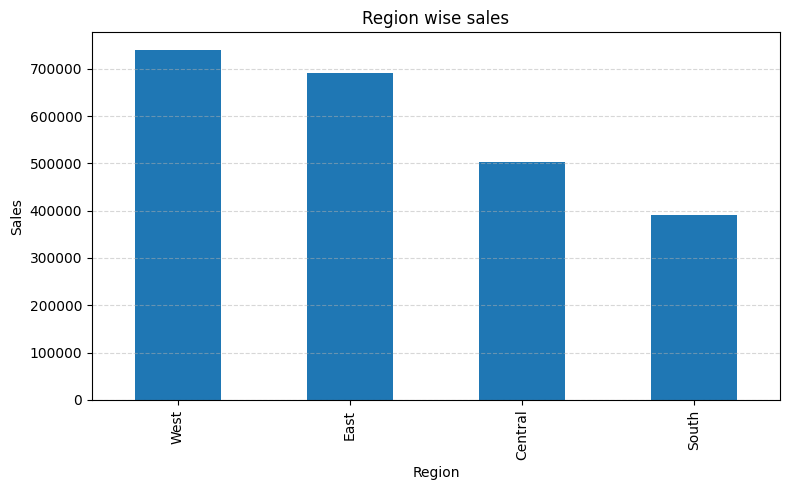

In [21]:
# Which Region generates the highest sales?

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending = False)

region_sales.plot(kind = "bar",  figsize=(8,5))
plt.title("Region wise sales")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

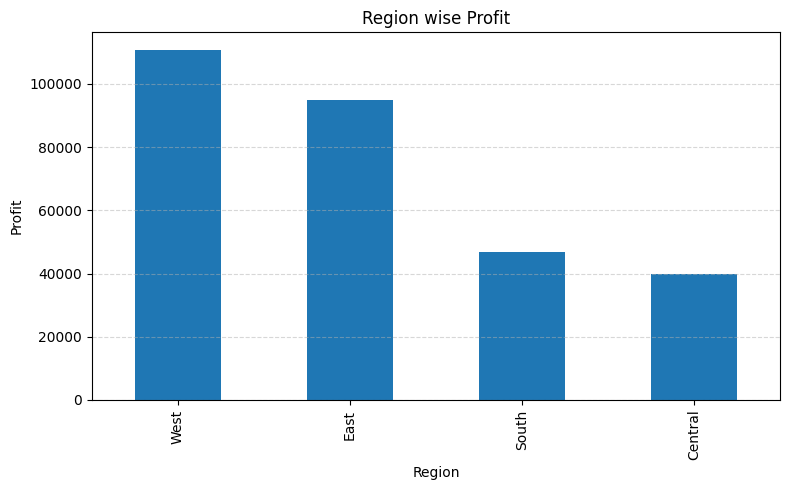

In [22]:
# Which Region earns the highest profit?

region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending = False)

region_profit.plot(kind = "bar", figsize=(8,5))
plt.title("Region wise Profit")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

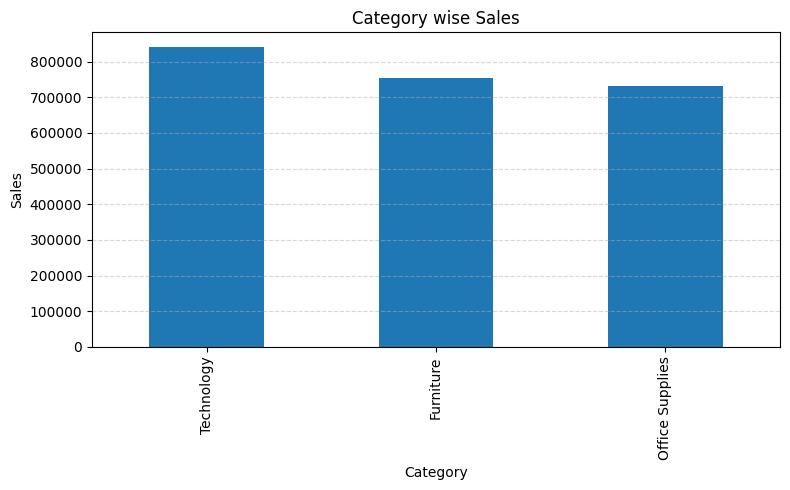

In [23]:
# Which Category has the highest sales?

catg_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending = False)

catg_sales.plot(kind = "bar", figsize=(8,5))
plt.title("Category wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

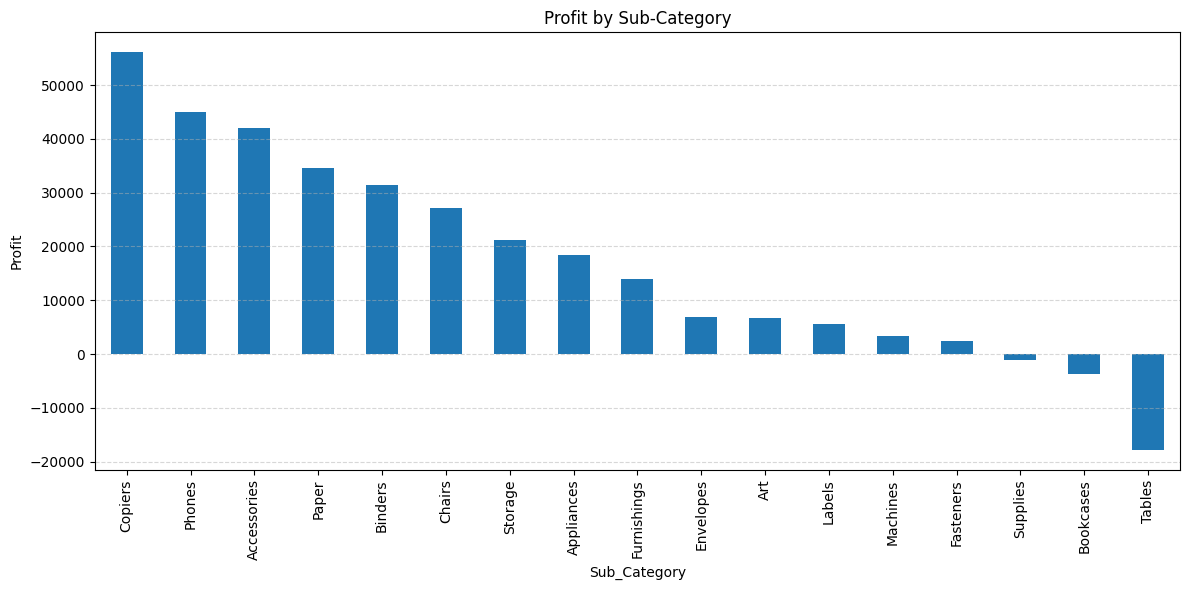

In [24]:
# Which Sub-Category is most profitable?

sub_catg_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values(ascending = False)

sub_catg_profit.plot(kind = "bar", figsize=(12,6))
plt.title("Profit by Sub-Category")
plt.xlabel("Sub_Category")
plt.ylabel("Profit")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

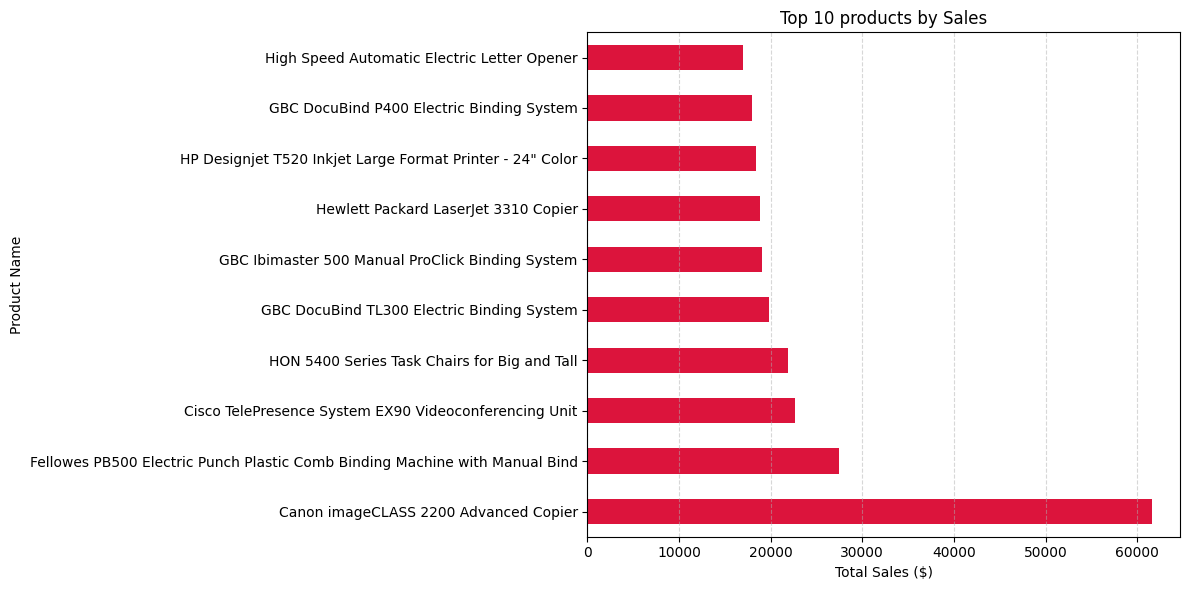

In [25]:
# Top 10 products by Sales

top_10_Sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

top_10_Sales.plot(kind = "barh", color='crimson', figsize=(12,6))
plt.title("Top 10 products by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Product Name")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

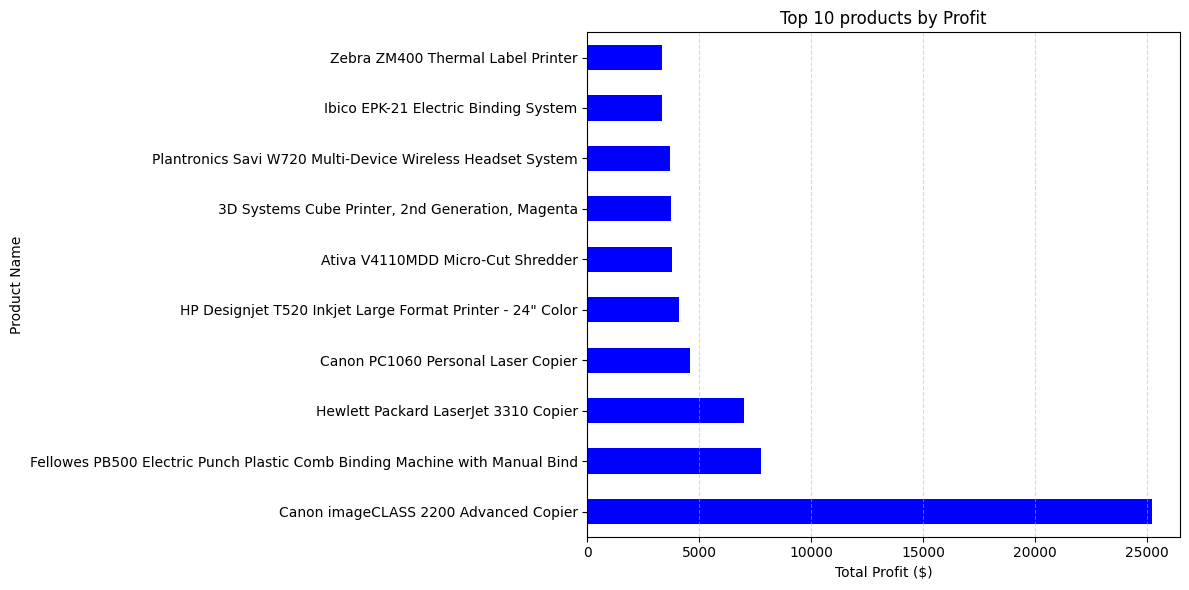

In [26]:
# Top 10 products by Profit

top_10_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)

top_10_profit.plot(kind = "barh", color='b', figsize=(12,6))
plt.title("Top 10 products by Profit")
plt.xlabel("Total Profit ($)")
plt.ylabel("Product Name")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

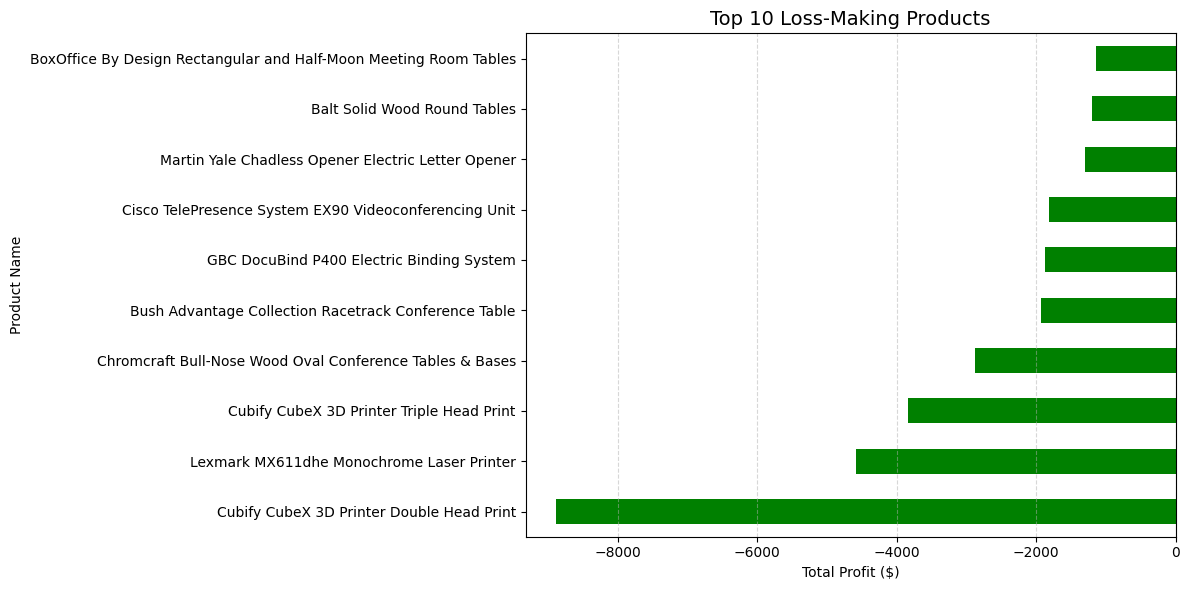

In [27]:
# Which Products are Causing the Highest Losses?

loss_products = (df.groupby('Product Name')['Profit'].sum().sort_values(ascending=True).head(10))

plt.figure(figsize=(12, 6))

loss_products.plot(kind='barh',color='g')

plt.title('Top 10 Loss-Making Products', fontsize=14)
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

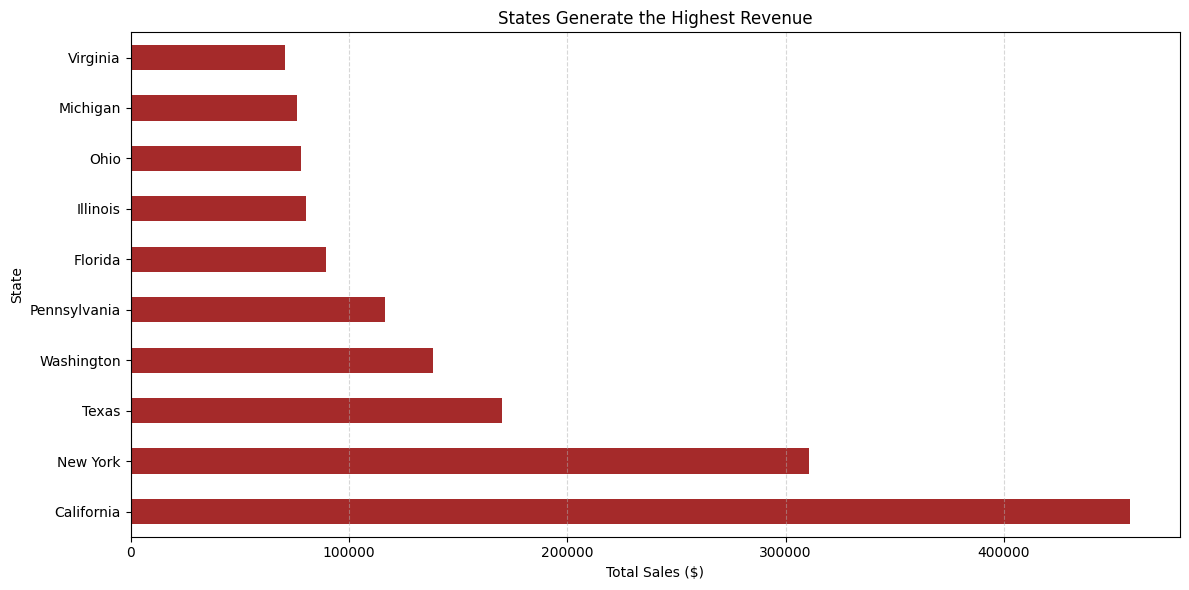

In [28]:
# Which states generate the highest revenue?

top_10_state = df.groupby("State/Province")["Sales"].sum().sort_values(ascending=False).head(10)

top_10_state.plot(kind = "barh", color = "brown", figsize=(12,6))
plt.title("States Generate the Highest Revenue")
plt.xlabel("Total Sales ($)")
plt.ylabel("State")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

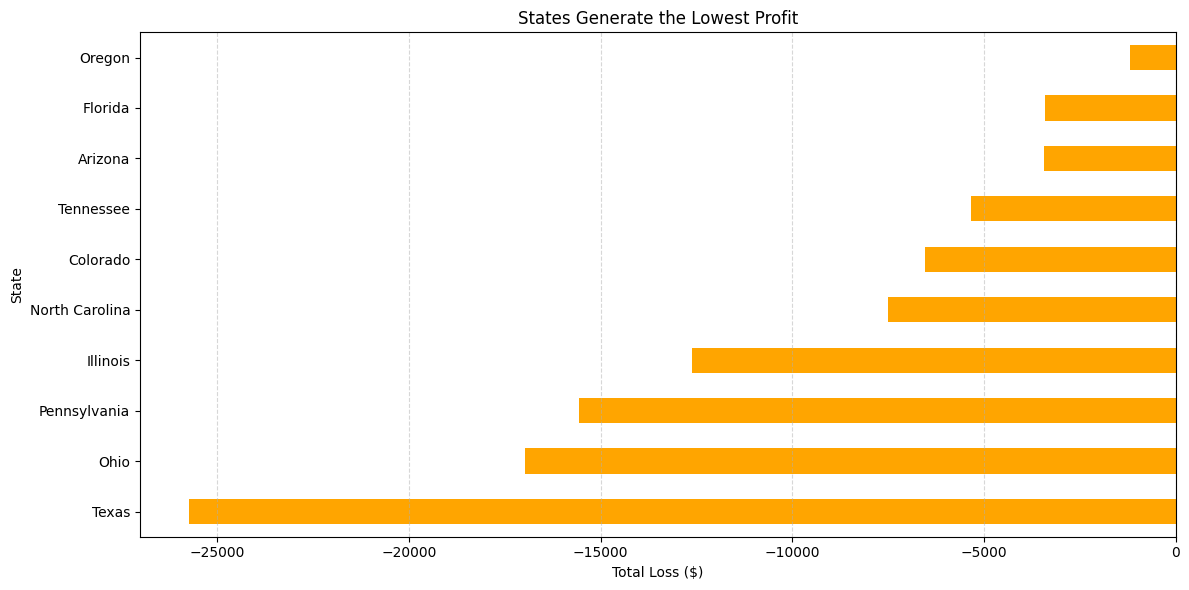

In [29]:
# Which states lose money? Lowest profit

low_state_profit = df.groupby("State/Province")["Profit"].sum().sort_values(ascending=True).head(10)

low_state_profit.plot(kind = "barh", color = "orange", figsize=(12,6))
plt.title("States Generate the Lowest Profit")
plt.xlabel("Total Loss ($)")
plt.ylabel("State")

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

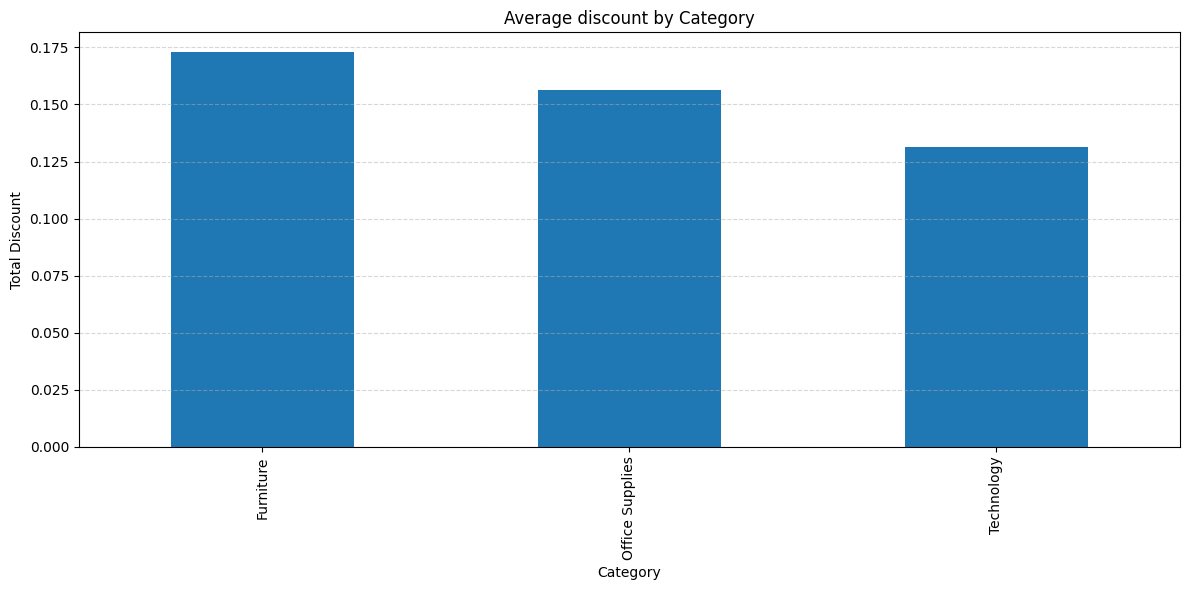

In [30]:
# Average discount by Category

avg_disc_catg = df.groupby("Category")["Discount"].mean().sort_values(ascending=False).head(10)

avg_disc_catg.plot(kind = "bar", figsize=(12,6))
plt.title("Average discount by Category")
plt.xlabel("Category")
plt.ylabel("Total Discount")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();

## Customer Analysis

Include:

- Top Customers
- Customer Segments
- Customers with Most Orders

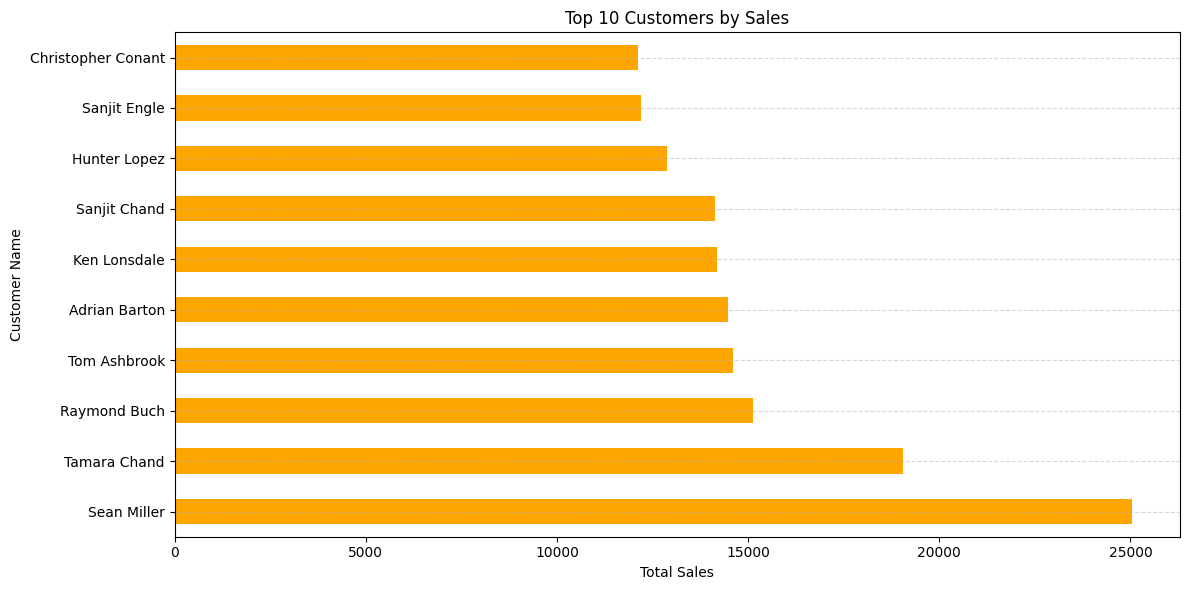

In [31]:
# Top 10 Customers by Sales

customer_most_ord = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10)

customer_most_ord.plot(kind = "barh", color = "orange", figsize=(12,6))
plt.title("Top 10 Customers by Sales")
plt.ylabel("Customer Name")
plt.xlabel("Total Sales")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();


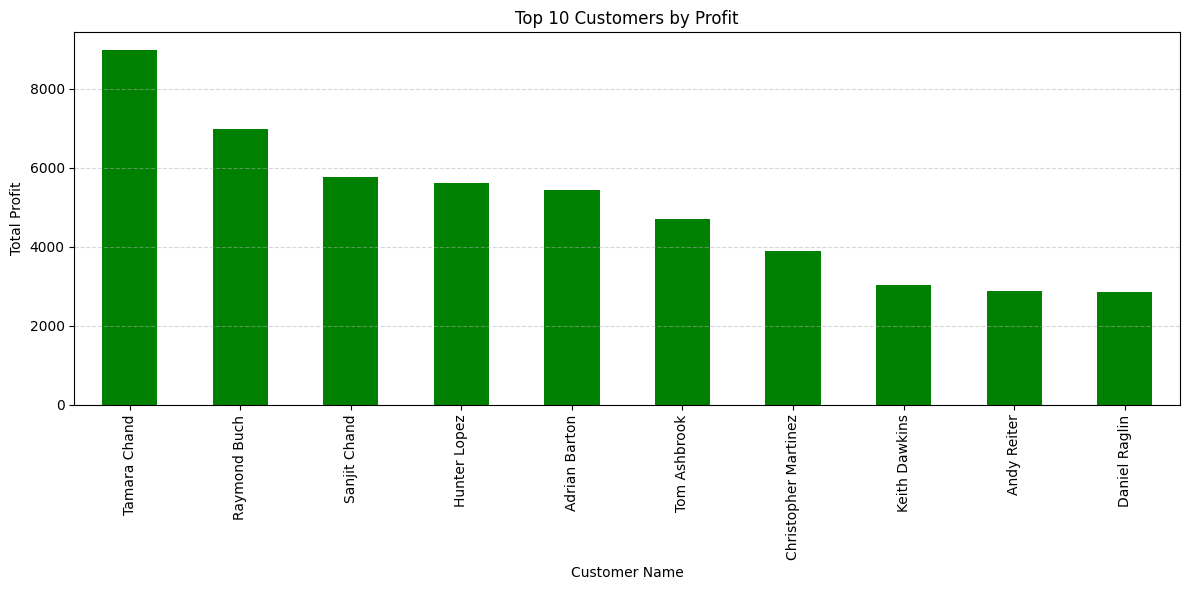

In [32]:
# Top 10 Customers by Profit

top_cust_profit = df.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10)

top_cust_profit.plot(kind = "bar", color = "g", figsize=(12,6))
plt.title("Top 10 Customers by Profit")
plt.xlabel("Customer Name")
plt.ylabel("Total Profit")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();


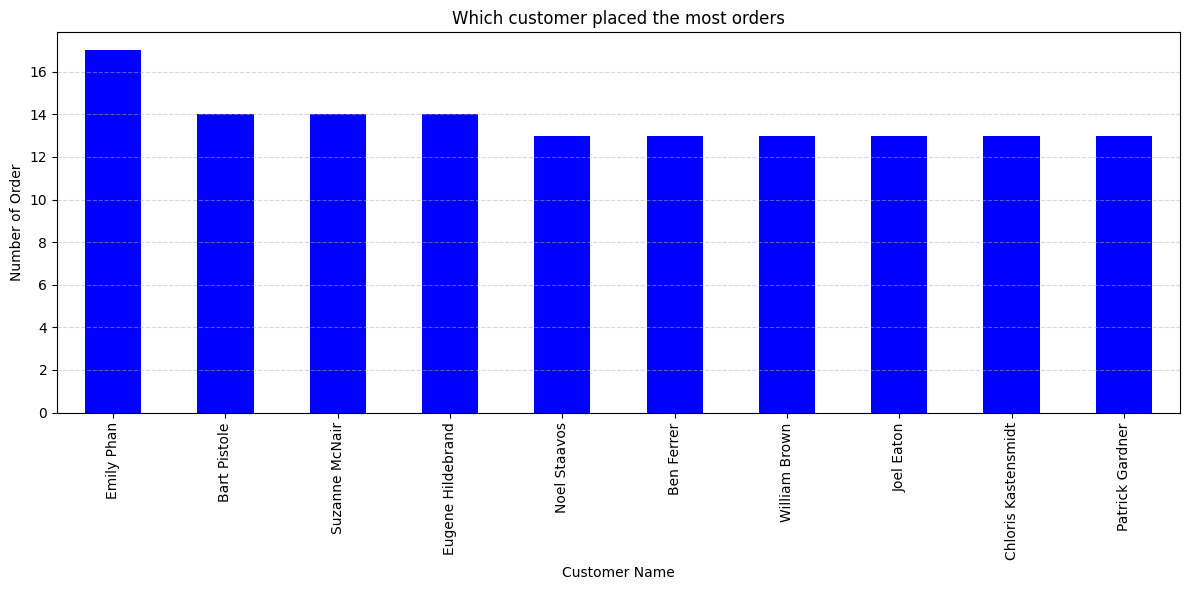

In [33]:
# Which customer placed the most orders?

customer_most_ord = (df.groupby('Customer Name')['Order ID'].nunique().sort_values(ascending=False).head(10))

customer_most_ord.plot(kind = "bar", color = "b", figsize=(12,6))
plt.title("Which customer placed the most orders")
plt.xlabel("Customer Name")
plt.ylabel("Number of Order")

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show();


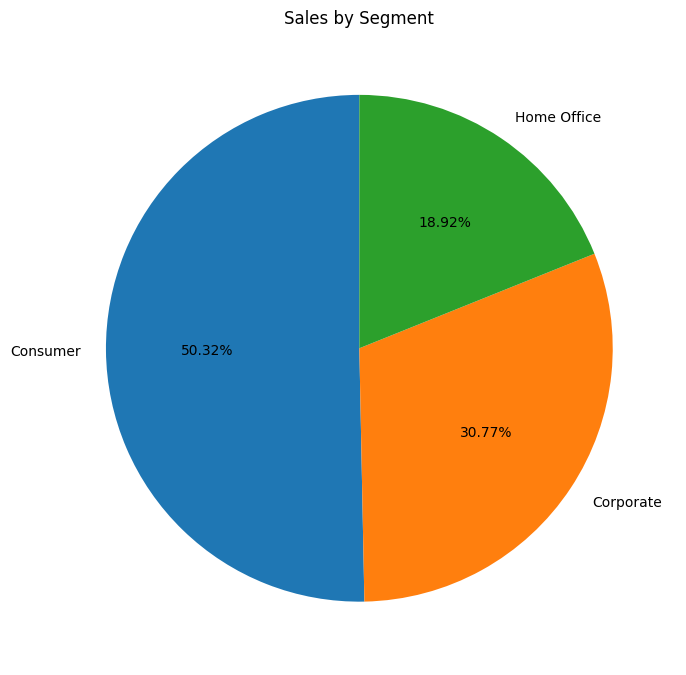

In [34]:
# Sales by Segment

sales_segments = df.groupby("Segment")["Sales"].sum()

plt.figure(figsize=(7,7))

plt.pie(
    sales_segments,
    labels=sales_segments.index,
    autopct="%2.2f%%",
    startangle=90
)

plt.title(
"Sales by Segment"
)

# plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Time Series Analysis

Include:

- Monthly Sales Trend
- Monthly Profit Trend
- Yearly Sales
- Yearly Profit



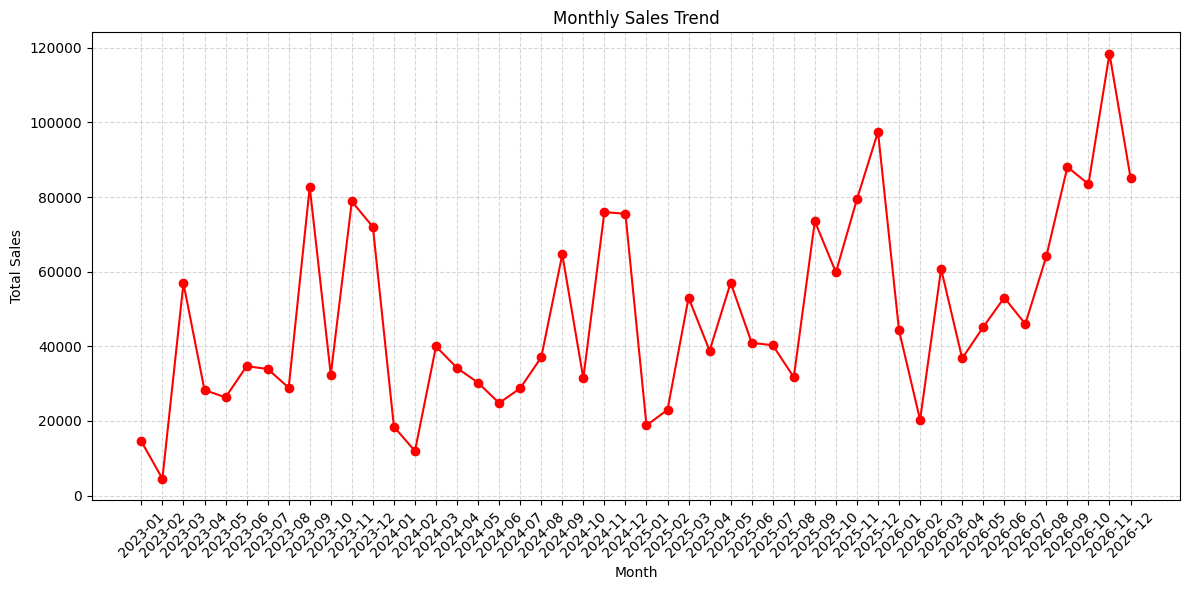

In [35]:
# Monthly Sales Trend 
sales_trend = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()

plt.figure(figsize=(12, 6))

plt.plot(sales_trend.index.astype(str), sales_trend.values, marker='o', color = "r")

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

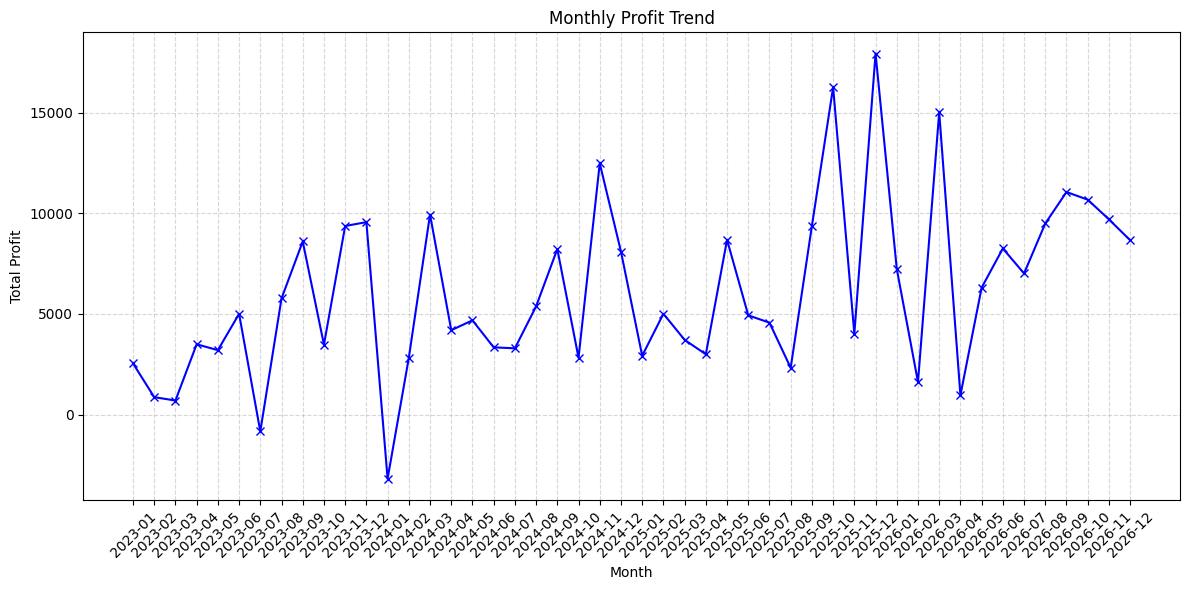

In [36]:
# Monthly Profit Trend

profit_trend = df.groupby("Order Month")["Profit"].sum()
plt.figure(figsize=(12,6))

plt.plot(profit_trend.index.astype(str), profit_trend.values, marker='x', color = "b")

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()

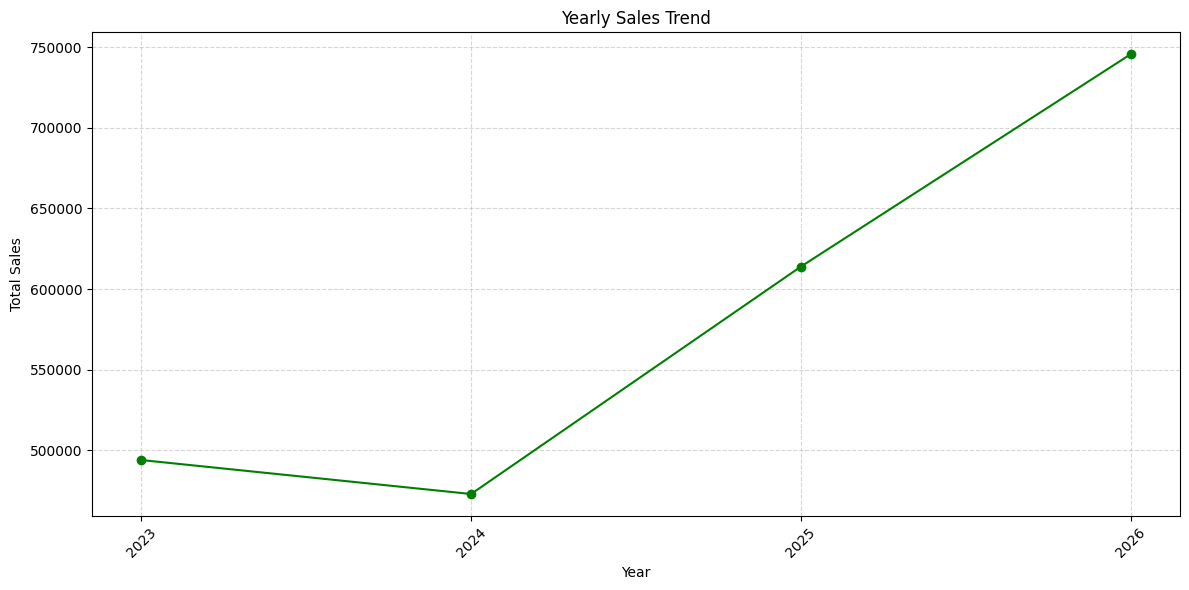

In [37]:
# Yearly Sales

yearly_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure(figsize=(12, 6))

plt.plot(yearly_sales.index.astype(str), yearly_sales.values, marker='o', color = "g")

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


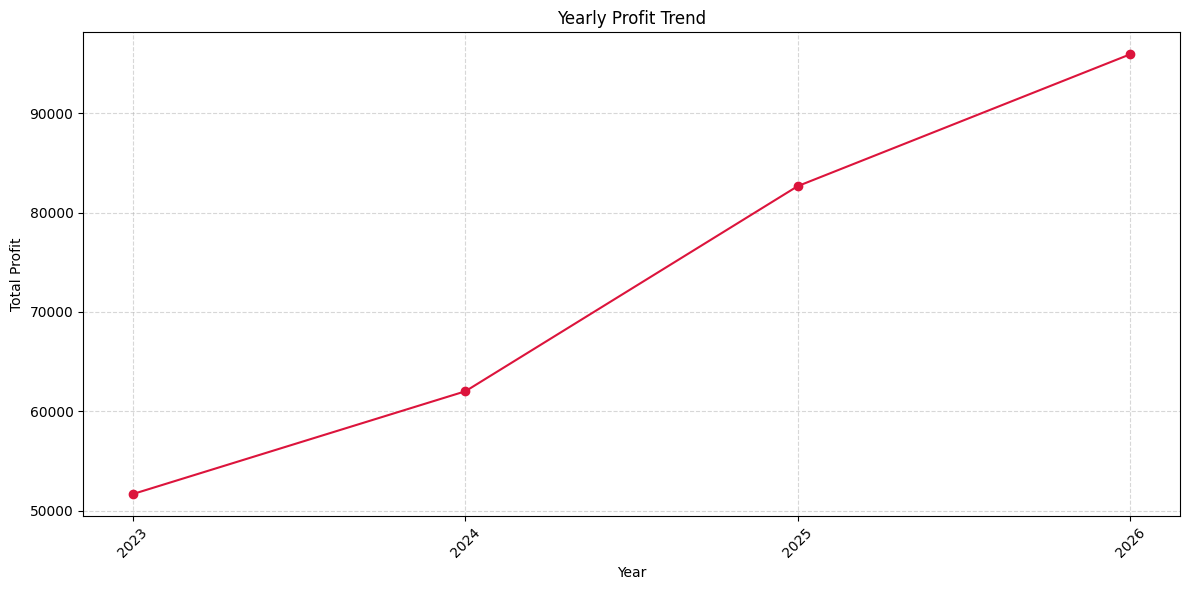

In [38]:
# Yearly Profit

yearly_profit = df.groupby("Order Year")["Profit"].sum()

plt.figure(figsize=(12, 6))

plt.plot(yearly_profit.index.astype(str), yearly_profit.values, marker='o', color = "crimson")

plt.title('Yearly Profit Trend')
plt.xlabel('Year')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Shipping Analysis

Include:

- Average Shipping Days
- Ship Mode Analysis
- Profit by Ship Mode

In [39]:
# Average Shipping Days

avg_ship = df['Shipping Days'].mean()
print(f"Average Shipping Days: {avg_ship:.2f}")

Average Shipping Days: 3.96


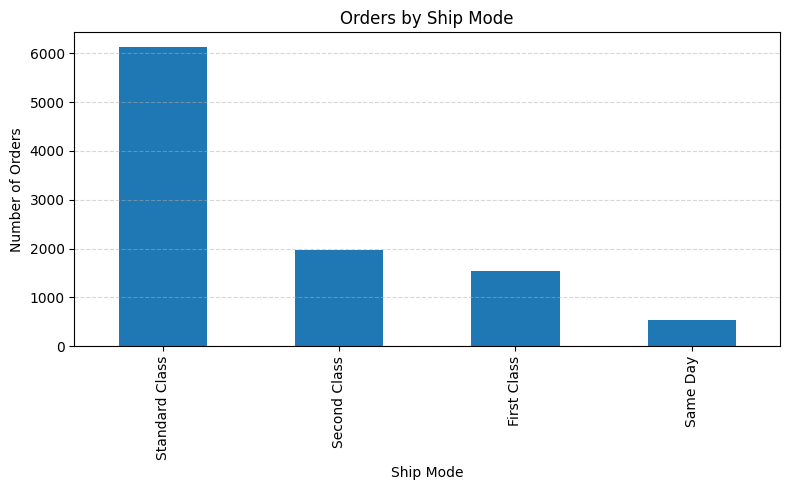

In [40]:
# Which Ship Mode is used the most?

ship_mode = df['Ship Mode'].value_counts()

ship_mode.plot(
    kind='bar',
    figsize=(8,5),
    title='Orders by Ship Mode'
)

plt.xlabel('Ship Mode')
plt.ylabel('Number of Orders')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()


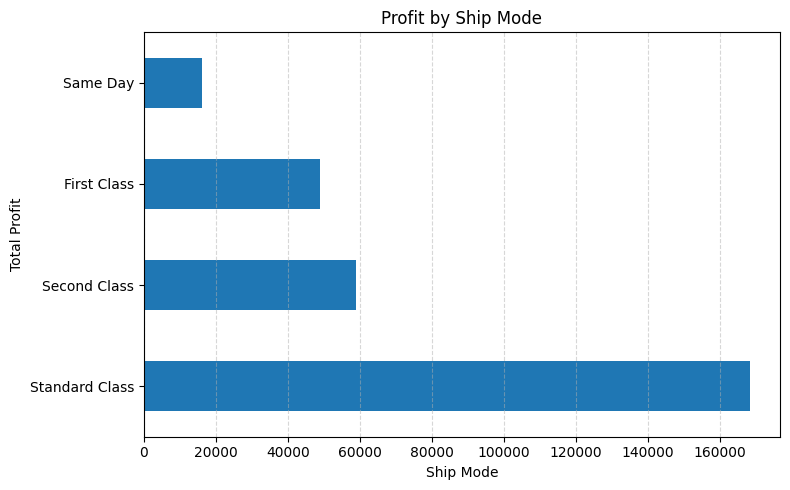

In [41]:
# Which Ship Mode gives the highest profit?

ship_mode_profit = df.groupby('Ship Mode')['Profit'].sum().sort_values(ascending=False)
ship_mode_profit.plot(
    kind='barh',
    figsize=(8,5),
    title='Profit by Ship Mode'
)

plt.xlabel('Ship Mode')
plt.ylabel('Total Profit')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()



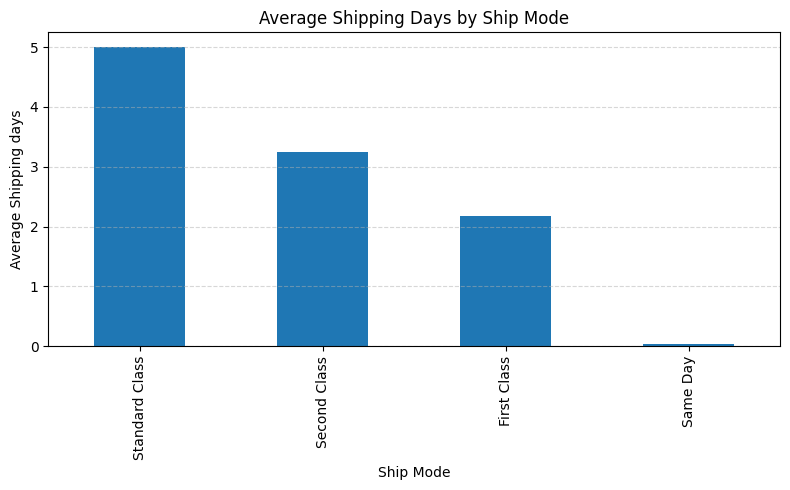

In [42]:
# Average Shipping Days by Ship Mode

avg_ship_mode = df.groupby('Ship Mode')['Shipping Days'].mean().sort_values(ascending=False)

avg_ship_mode.plot(
    kind='bar',
    figsize=(8,5),
    title='Average Shipping Days by Ship Mode'
)

plt.xlabel('Ship Mode')
plt.ylabel('Average Shipping days')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Correlation Analysis

Correlation analysis helps identify relationships between numerical variables such as Sales, Profit, Quantity, and Discount.

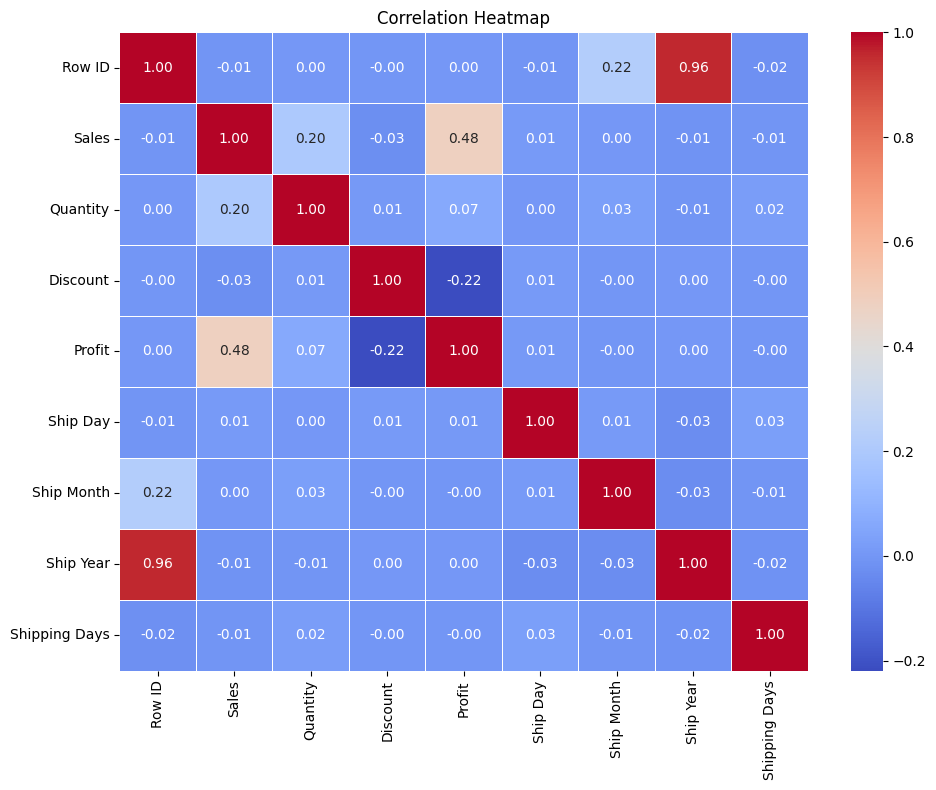

In [43]:
# Correlation Analysis

numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()


plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

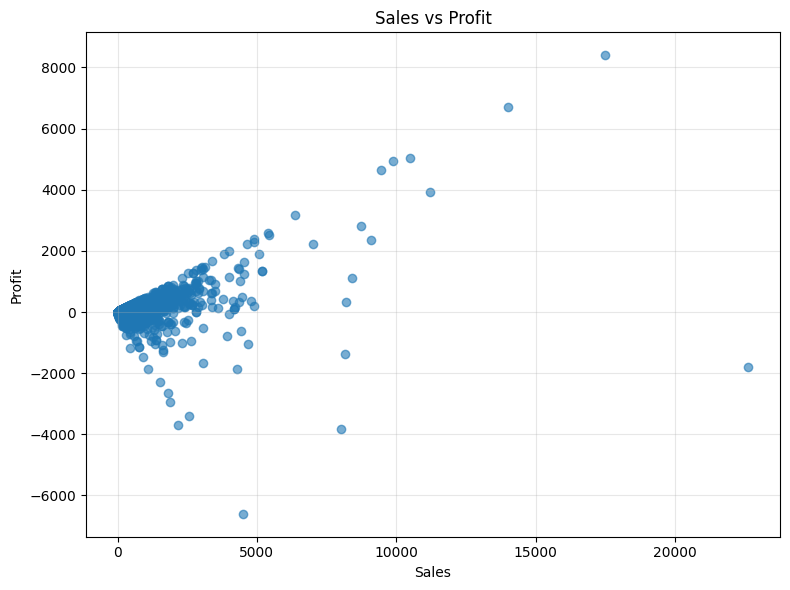

In [44]:
# Relationship Between Sales and Profit (Scatter Plot)

plt.figure(figsize=(8,6))

plt.scatter(df['Sales'], df['Profit'], alpha=0.6)

plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

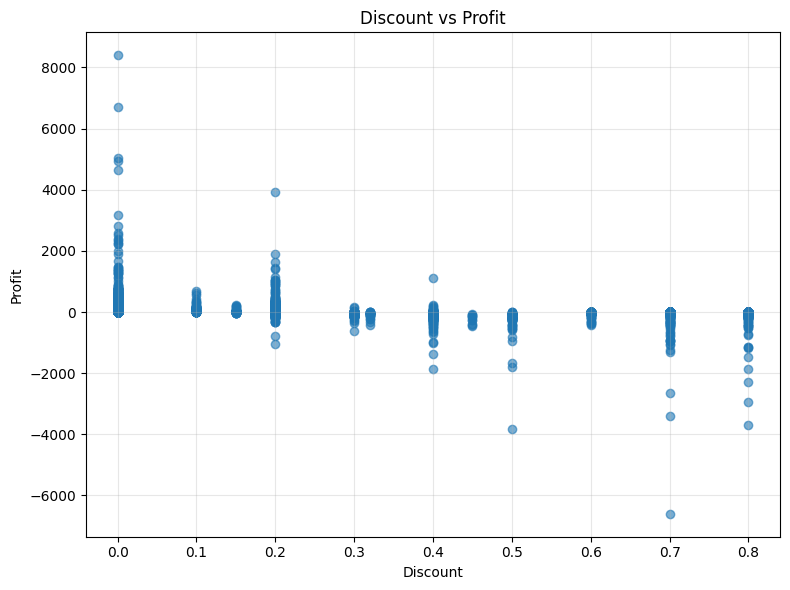

In [45]:
# Relationship Between Discount and Profit

plt.figure(figsize=(8,6))

plt.scatter(df['Discount'], df['Profit'], alpha=0.6)

plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

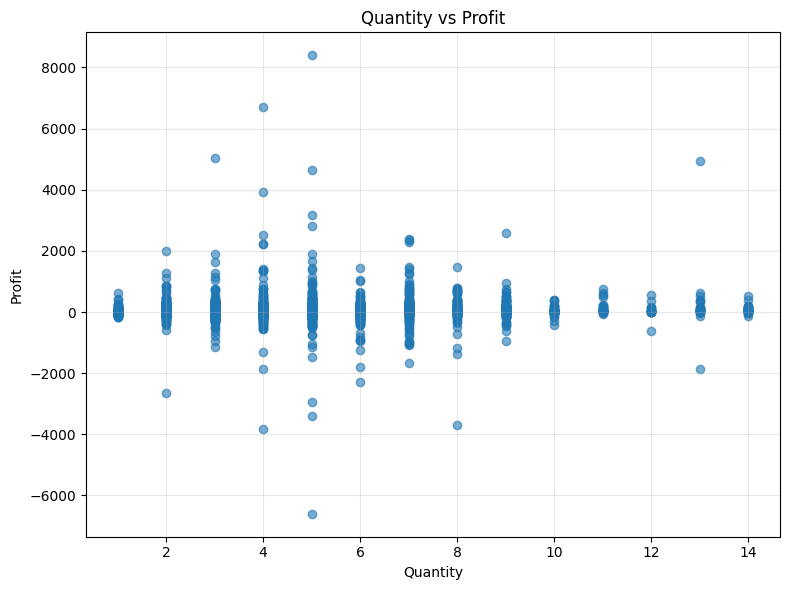

In [46]:
# Relationship Between Quantity and Profit

plt.figure(figsize=(8,6))

plt.scatter(df['Quantity'], df['Profit'], alpha=0.6)

plt.title('Quantity vs Profit')
plt.xlabel('Quantity')
plt.ylabel('Profit')

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Key Findings (Business Insights)


1. The West region generated the highest total sales, making it the strongest-performing region.

2. The Technology category produced the highest revenue among all product categories.

3. The Technology category was also the most profitable, indicating strong margins.

4. Some products generated high sales but relatively low profits, suggesting that high revenue does not always translate into high profitability.

5. Several products recorded negative profits, indicating losses that may be caused by excessive discounts or high costs.

6. The Consumer segment contributed the largest share of total sales.

7. A small number of customers contributed significantly to total revenue, highlighting the importance of retaining high-value customers.

8. Sales showed noticeable fluctuations throughout the year, indicating seasonal purchasing patterns.

9. The most frequently used shipping method handled the majority of customer orders, demonstrating customer preference for that shipping option.

10. Discounts showed a negative relationship with profit, suggesting that larger discounts generally reduce profitability.

11. Sales and Profit exhibited a positive correlation, meaning higher sales often resulted in higher profits.

12. Quantity sold had only a weak relationship with profit, indicating that increasing sales volume alone does not guarantee higher earnings.

## Business Recommendations

- Reduce excessive discounts on low-margin products.
- Focus marketing efforts on high-profit products.
- Increase inventory for top-selling products.
- Investigate products generating continuous losses.
- Improve sales performance in lower-performing regions.
- Reward loyal customers through targeted promotions.
- Optimize shipping methods to reduce delivery time and costs.
- Continue investing in profitable product categories such as Technology.


## Conclusion

This project explored the Superstore dataset using Python, Pandas, Matplotlib, and Seaborn to analyze sales performance and customer behavior. Through exploratory data analysis, several key business insights were identified regarding regional performance, product profitability, customer purchasing patterns, shipping efficiency, and the impact of discounts on profit. The findings can help businesses make data-driven decisions related to pricing, inventory management, customer retention, and operational efficiency. This project also demonstrates practical data analysis skills including data cleaning, feature engineering, visualization, and business storytelling.

## Limitations

- The analysis is based on historical transaction data only.
- External factors such as inflation, competitor pricing, and customer demographics are not included.
- The project focuses on descriptive analytics rather than predictive modeling.